In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = wrds.Connection()

Enter your WRDS username [zhangyining]: yiningzhang24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
ticker = 'AAPL'
start_date = '2023-01-01'
end_date = '2023-12-31'

In [5]:
sql = f"""
    select date, prc as adj_close, vol
    from crsp.dsf
    where permco in (select permco from crsp.stocknames where ticker='{ticker}')
    and date between '{start_date}' and '{end_date}'
"""
df = conn.raw_sql(sql)

In [6]:

print(df.shape)
print(df.head())
print(df.isna().sum())

(250, 3)
         date  adj_close          vol
0  2023-01-03     125.07  111953221.0
1  2023-01-04     126.36   89022192.0
2  2023-01-05     125.02   81128113.0
3  2023-01-06     129.62   87654520.0
4  2023-01-09  130.14999   70700396.0
date         0
adj_close    0
vol          0
dtype: int64


In [7]:

df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [8]:

df['daily_return'] = df['adj_close'].pct_change()

In [9]:

print(df[['adj_close', 'daily_return']].describe())

       adj_close  daily_return
count      250.0         249.0
mean   172.54896      0.001812
std    17.331644      0.012565
min       125.02      -0.04802
25%     162.1125     -0.006162
50%    175.47501      0.001797
75%       187.33      0.008846
max       198.11      0.046927


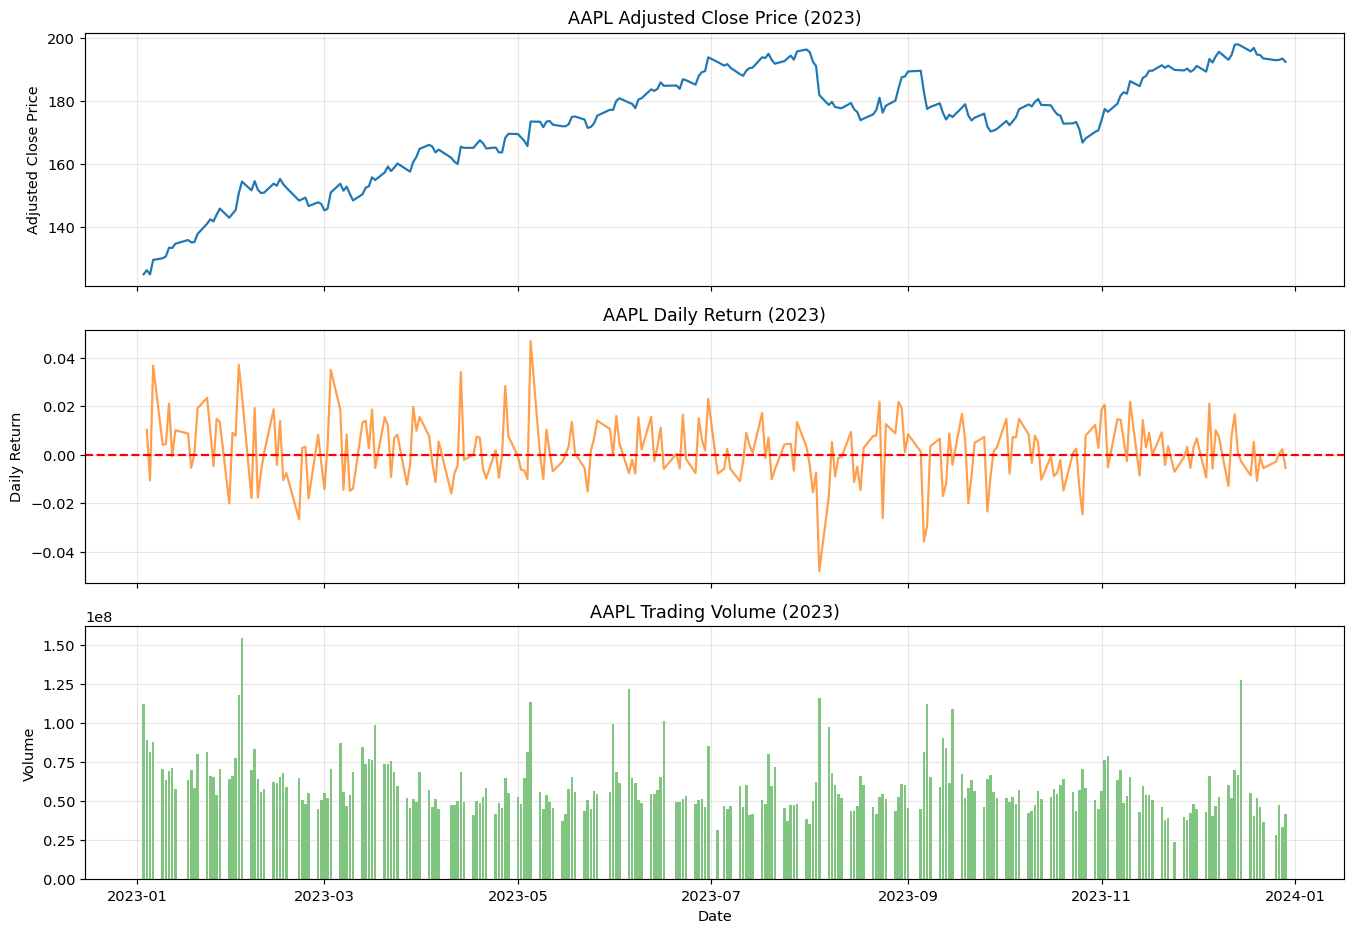

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 105

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax1.plot(df['adj_close'], color='#1f77b4')
ax1.set_title(f'{ticker} Adjusted Close Price (2023)', fontsize=12)
ax1.set_ylabel('Adjusted Close Price')
ax1.grid(alpha=0.3)

ax2.plot(df['daily_return'], color='#ff7f0e', alpha=0.75)
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_title(f'{ticker} Daily Return (2023)', fontsize=12)
ax2.set_ylabel('Daily Return')
ax2.grid(alpha=0.3)

ax3.bar(df.index, df['vol'], color='#2ca02c', alpha=0.6)
ax3.set_title(f'{ticker} Trading Volume (2023)', fontsize=12)
ax3.set_ylabel('Volume')
ax3.set_xlabel('Date')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()